In [1]:
!pip install fvcore av pytorchvideo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 58.2 MB/s eta 0:00:00:00:0100:01
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=999ddd6002bc275f2e9c6f8f7779181e09757f16b7b34b08bccf27f6986b2005
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for pytorchvideo: filename=pytorchvideo-0.1.5-py3-none-any.whl size=188686 sha256=685b695dddfc655d7e582fea0031443c09409e94429a5ddbac229b8c9cd28532
  Stored in directory: /root/.cache/pip/wheels/b3/49/dc/aab2dce83e38b59849db13a4f4ddd220e568e24b58332fb0f9
  Crea

/kaggle/input/datasets/sundye/wlasl300/WLASL_300/

In [2]:
import os
import cv2
import time
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader

DATA_DIR = "/kaggle/input/datasets/sundye/wlasl300/WLASL_300/"
BATCH_SIZE = 8
LR = 1e-4
WD = 1e-4
EPOCHS = 30
SAVE_PATH = "best_slowfast_wlasl300.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TOTAL_FRAMES   = 32      
SAMPLING_RATE  = 2       
ALPHA          = 4       
SLOW_FRAMES    = TOTAL_FRAMES // ALPHA   
FAST_FRAMES    = TOTAL_FRAMES            
CROP_SIZE      = 224
MEAN           = [0.45, 0.45, 0.45]
STD            = [0.225, 0.225, 0.225]

TRAIN_CLIPS    = 1   
VAL_CLIPS      = 1
TEST_CLIPS     = 2  



def random_short_side_scale(frames, min_size=256, max_size=320):
    h, w = frames.shape[1], frames.shape[2]
    new_short = np.random.randint(min_size, max_size + 1)
    if h < w:
        new_h, new_w = new_short, int(w * new_short / h)
    else:
        new_h, new_w = int(h * new_short / w), new_short
    return np.stack([cv2.resize(f, (new_w, new_h)) for f in frames])


def random_crop(frames, crop_size):
    h, w = frames.shape[1], frames.shape[2]
    top  = np.random.randint(0, h - crop_size + 1)
    left = np.random.randint(0, w - crop_size + 1)
    return frames[:, top:top + crop_size, left:left + crop_size]


def random_flip(frames):
    if np.random.rand() < 0.5:
        frames = frames[:, :, ::-1].copy()
    return frames


def uniform_crop(frames, crop_size, spatial_idx):
    h, w = frames.shape[1], frames.shape[2]
    if w > h:                           
        short = h
        long  = w
        scale = crop_size / short
        new_h = crop_size
        new_w = int(long * scale)
        frames = np.stack([cv2.resize(f, (new_w, new_h)) for f in frames])
        x_start = {0: 0, 1: (new_w - crop_size) // 2,
                   2: new_w - crop_size}[spatial_idx]
        return frames[:, :, x_start:x_start + crop_size]
    else:                               
        short = w
        long  = h
        scale = crop_size / short
        new_w = crop_size
        new_h = int(long * scale)
        frames = np.stack([cv2.resize(f, (new_w, new_h)) for f in frames])
        y_start = {0: 0, 1: (new_h - crop_size) // 2,
                   2: new_h - crop_size}[spatial_idx]
        return frames[:, y_start:y_start + crop_size]



def sample_frames_uniform(video_path, num_frames, sampling_rate, temporal_idx,
                           num_clips):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    clip_len = num_frames * sampling_rate          

    if total <= 0:
        cap.release()
        return np.zeros((num_frames, 256, 256, 3), dtype=np.uint8)

    if total < clip_len:
        all_frames = []
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        while True:
            ret, f = cap.read()
            if not ret:
                break
            all_frames.append(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
        cap.release()
        while len(all_frames) < clip_len:
            all_frames.append(all_frames[-1])
        raw = np.stack(all_frames)
    else:
        if num_clips == 1:
            start = np.random.randint(0, total - clip_len + 1)
        else:
            gap   = (total - clip_len) / float(num_clips)
            start = int(gap * temporal_idx)
            start = max(0, min(start, total - clip_len))

        raw_frames = []
        cap.set(cv2.CAP_PROP_POS_FRAMES, start)
        for _ in range(clip_len):
            ret, f = cap.read()
            if not ret:
                raw_frames.append(raw_frames[-1] if raw_frames else
                                  np.zeros((256, 256, 3), np.uint8))
            else:
                raw_frames.append(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
        cap.release()
        raw = np.stack(raw_frames)   

    indices = np.arange(num_frames) * sampling_rate
    return raw[indices]


def normalize(frames):
    x = frames.astype(np.float32) / 255.0
    mean = np.array(MEAN, dtype=np.float32)
    std  = np.array(STD,  dtype=np.float32)
    return (x - mean) / std


def to_slow_fast(frames_fast):
    slow_idx    = np.arange(SLOW_FRAMES) * ALPHA          
    frames_slow = frames_fast[slow_idx]

    fast = torch.from_numpy(frames_fast).permute(3, 0, 1, 2).float()
    slow = torch.from_numpy(frames_slow).permute(3, 0, 1, 2).float()
    return slow, fast



class WLASLDataset(Dataset):


    def __init__(self, root_dir, mode='train'):
        self.mode = mode
        split_dir = os.path.join(root_dir, mode)
        if not os.path.exists(split_dir):
            raise FileNotFoundError(f"Path not found: {split_dir}")

        self.classes      = sorted(os.listdir(split_dir))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        base_samples = []
        for cls in self.classes:
            cls_path = os.path.join(split_dir, cls)
            for vid in os.listdir(cls_path):
                if vid.endswith('.mp4'):
                    base_samples.append(
                        (os.path.join(cls_path, vid), self.class_to_idx[cls]))

        if mode == 'test':
            self.samples = [
                (path, label, t_idx, s_idx)
                for path, label in base_samples
                for t_idx in range(TEST_CLIPS)
                for s_idx in range(3)
            ]
        elif mode == 'train':
            self.samples = [
                (path, label, c_idx, -1)
                for path, label in base_samples
                for c_idx in range(TRAIN_CLIPS)
            ]
        else:  # val
            self.samples = [
                (path, label, 0, 1)   
                for path, label in base_samples
            ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        if self.mode == 'test':
            path, label, temporal_idx, spatial_idx = self.samples[idx]
        else:
            path, label, clip_idx, spatial_idx = self.samples[idx]
            temporal_idx = clip_idx   

        num_clips = (TEST_CLIPS if self.mode == 'test' else
                     TRAIN_CLIPS if self.mode == 'train' else VAL_CLIPS)
        frames = sample_frames_uniform(
            path, FAST_FRAMES, SAMPLING_RATE, temporal_idx, num_clips)
        
        if self.mode == 'train' or self.mode == 'val':
            frames = random_short_side_scale(frames, 256, 320)
            frames = random_crop(frames, CROP_SIZE)
            frames = random_flip(frames)
        else: 
            h, w = frames.shape[1], frames.shape[2]
            short = min(h, w)
            scale = 256 / short
            new_h, new_w = int(h * scale), int(w * scale)
            frames = np.stack([cv2.resize(f, (new_w, new_h)) for f in frames])
            frames = uniform_crop(frames, CROP_SIZE, spatial_idx)
        
        frames = normalize(frames)
        slow, fast = to_slow_fast(frames)

        return [slow, fast], label


# Model 

def build_slowfast_wlasl(num_classes=300):
    model = torch.hub.load('facebookresearch/pytorchvideo',
                           'slowfast_r50', pretrained=True)
    in_features = model.blocks[6].proj.in_features
    model.blocks[6].proj = nn.Linear(in_features, num_classes)
    return model


# Data Loaders 

train_loader = DataLoader(WLASLDataset(DATA_DIR, 'train'),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(WLASLDataset(DATA_DIR, 'val'),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(WLASLDataset(DATA_DIR, 'test'),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Model / Loss / Optimizer 

model     = build_slowfast_wlasl(num_classes=300).to(device)
model.blocks[6].dropout = nn.Dropout(p=0.5)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_acc = 0.0

# Training loop 
train_losses = []
val_losses   = []

total_train_start = time.time()
epoch_durations   = []

print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} "
      f"{'Val Loss':<12} {'Val Acc':<12} {'Time (s)':<10}")
print("-" * 85)

for epoch in range(EPOCHS):
    epoch_start = time.time()

    # Training
    model.train()
    train_loss = train_correct = train_total = 0
    for inputs, labels in train_loader:
        inputs = [i.to(device) for i in inputs]
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total   += labels.size(0)

    # Validation
    model.eval()
    val_loss = val_correct = val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = [i.to(device) for i in inputs]
            labels = labels.to(device)
            outputs   = model(inputs)
            val_loss    += criterion(outputs, labels).item()
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    
    scheduler.step()

    duration = time.time() - epoch_start
    epoch_durations.append(duration)

    avg_val_acc = 100 * val_correct / val_total
    save_msg = ""
    if avg_val_acc > best_val_acc:
        best_val_acc = avg_val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        torch.save(model, SAVE_PATH.replace('.pth', '_full.pth'))
        save_msg = "*"

    print(f"{epoch+1:<8} {train_loss/len(train_loader):<12.4f} "
          f"{100*train_correct/train_total:<12.2f} "
          f"{val_loss/len(val_loader):<12.4f} {avg_val_acc:<12.2f} "
          f"{duration:<10.2f} {save_msg}")

total_time = time.time() - total_train_start
print("-" * 85)
print(f"Training Finished!")
print(f"Overall Training Time: {total_time / 60:.2f} minutes")
print(f"Average Time per Epoch: {sum(epoch_durations)/len(epoch_durations):.2f} seconds")
print("-" * 85)

# Final test evaluation 
print("Running Final Evaluation on TEST set...")
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

from collections import defaultdict
video_logits = defaultdict(lambda: torch.zeros(300))
video_labels = {}

test_dataset = test_loader.dataset
raw_loader   = test_loader

with torch.no_grad():
    sample_idx = 0
    for inputs, labels in raw_loader:
        inputs  = [i.to(device) for i in inputs]
        outputs = model(inputs)
        probs   = torch.softmax(outputs, dim=1).cpu()
        for b in range(labels.size(0)):
            path, lbl, t_idx, s_idx = test_dataset.samples[sample_idx]
            video_logits[(path, lbl)] += probs[b]
            video_labels[(path, lbl)]  = lbl
            sample_idx += 1

correct_top1 = 0
correct_top5 = 0
for key, logits in video_logits.items():
    label = video_labels[key]
    correct_top1 += logits.argmax().item() == label
    correct_top5 += label in logits.topk(5).indices.tolist()

total = len(video_logits)
print(f"Final Test Top-1 Accuracy: {100 * correct_top1 / total:.2f}%")
print(f"Final Test Top-5 Accuracy: {100 * correct_top5 / total:.2f}%")

Downloading: "https://github.com/facebookresearch/pytorchvideo/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/pytorchvideo/model_zoo/kinetics/SLOWFAST_8x8_R50.pyth" to /root/.cache/torch/hub/checkpoints/SLOWFAST_8x8_R50.pyth


100%|██████████| 264M/264M [00:00<00:00, 344MB/s] 


Epoch    Train Loss   Train Acc    Val Loss     Val Acc      Time (s)  
-------------------------------------------------------------------------------------
1        5.6560       1.04         5.6795       2.66         873.97     *
2        5.0017       5.41         4.4045       12.10        884.83     *
3        4.0779       17.33        3.6351       26.75        885.59     *
4        3.4231       31.98        3.1571       39.62        885.67     *
5        2.8870       47.48        2.9276       45.73        886.06     *
6        2.4932       59.43        2.7569       52.05        885.46     *
7        2.1845       69.40        2.6422       56.27        884.64     *
8        1.9188       78.05        2.5726       57.71        884.55     *
9        1.7423       83.43        2.4485       60.71        884.53     *
10       1.5819       88.95        2.4529       60.49        884.39     
11       1.4696       92.14        2.2450       65.15        885.00     *
12       1.3805       94.28  

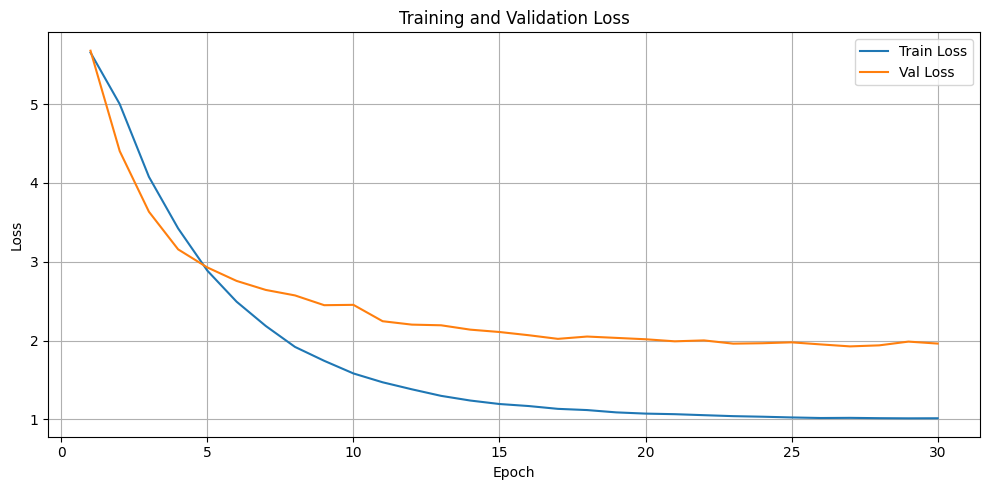

In [4]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_curve.png')
plt.show()